DATASET OVERVIEW
Shape: 768 rows, 9 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

 Basic statistics 
       Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin     BMI  \
count       768.00   768.00         768.00         768.00   768.00  768.00   
mean          

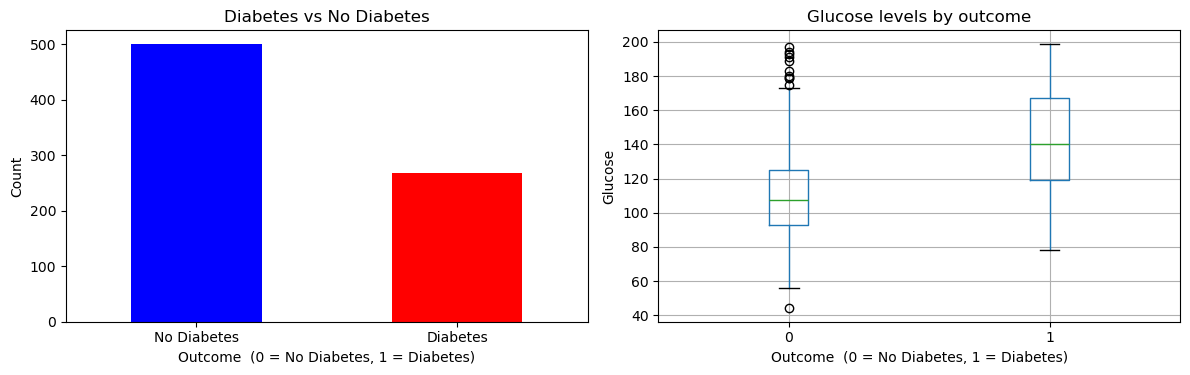

MODEL ACCURACY
Logistic Regression : 75.32%
Random Forest       : 73.38%

 Random Forest – Classification Report 
              precision    recall  f1-score   support

 No Diabetes       0.80      0.79      0.79        99
    Diabetes       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154



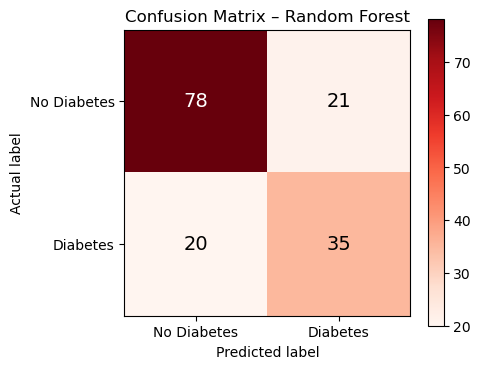

In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = [
    "Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
    "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"
]
df = pd.read_csv(url, header=None, names=columns)


print("DATASET OVERVIEW")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print()
print(df.info())
print()
print(" Basic statistics ")
print(df.describe().round(2))
print()
print(" Class distribution ")
print(df["Outcome"].value_counts())
print()


zero_columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
for col in zero_columns:
    df[col] = df[col].replace(0, np.nan)

df = df.fillna(df.median(numeric_only=True))

# Visualisations
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
df["Outcome"].value_counts().plot(kind="bar", ax=axes[0], color=["blue", "red"])
axes[0].set_title("Diabetes vs No Diabetes")
axes[0].set_xlabel("Outcome  (0 = No Diabetes, 1 = Diabetes)")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["No Diabetes", "Diabetes"], rotation=0)

# Box plot
df.boxplot(column="Glucose", by="Outcome", ax=axes[1])
axes[1].set_title("Glucose levels by outcome")
axes[1].set_xlabel("Outcome  (0 = No Diabetes, 1 = Diabetes)")
axes[1].set_ylabel("Glucose")
fig.suptitle("")

plt.tight_layout()
plt.show()

# . Prepare data for ML 
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

#  Train models
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# Results
print("MODEL ACCURACY")

print(f"Logistic Regression : {accuracy_score(y_test, log_pred):.2%}")
print(f"Random Forest       : {accuracy_score(y_test, rf_pred):.2%}")
print()

print(" Random Forest – Classification Report ")
print(classification_report(y_test, rf_pred,
      target_names=["No Diabetes", "Diabetes"]))

# Confusion matrix 
cm = confusion_matrix(y_test, rf_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Reds")
plt.colorbar(im, ax=ax)

labels = ["No Diabetes", "Diabetes"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
ax.set_title("Confusion Matrix – Random Forest")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=14)

plt.tight_layout()
plt.show()

